In [ ]:
#created 12/01/2025
#first simulation of the different samplers 

In [3]:
import numpy as np
import matplotlib.pyplot as plt 
import tqdm

In [4]:

#parabolic potential
def U_para(x):
    return 0.5*(np.dot(x,x))

#gradient
def gradU_para(x):
    return x

def U_anipara(x):
    x1,x2 = x
    return 0.5*x1**2 + 0.5*4*x2**2

def gradU_anipara(x):
    x1,x2 = x
    return np.array([x1, 4*x2])

#double valley potential
alpha = 5.0

def U_doublepara(x):
    x1, x2 = x
    return alpha*0.25*(x1**2 - 1)**2 +alpha* 0.5*x2**2

def gradU_doublepara(x):
    x1, x2 = x
    return np.array([alpha*x1*(x1**2 - 1),alpha*x2])

def U_4para(x):
    x1, x2 = x
    return alpha*0.25*(x1**2 - 1)**2 + alpha*0.25*(x2**2 - 1)**2

def gradU_4para(x):
    x1, x2 = x
    return np.array([alpha*x1*(x1**2 - 1), alpha*x2*(x2**2 - 1)])


In [5]:
#one single verlet step
def verlet_step(x, v, gradU, delta):
    
    v = v - 0.5 * delta * gradU(x)
    x = x + delta * v
    v = v - 0.5 * delta * gradU(x)

    return x, v

def hamiltonian_drift(x, v, gradU, delta, eta, K):
    
        X = np.zeros((K, len(x))) 
        V = np.zeros((K, len(v)))
        
        #K verlet steps 
        for i in range(K):
            x,v = verlet_step(x,v, gradU, delta)
            X[i] = x
            V[i] = v
        
        #velocity refresh
        v = eta * v + np.sqrt(1 - eta**2) * np.random.randn(*v.shape)
        
        return x,v,X,V
        

def sample_run(x0, v0, gradU, N, delta, K, eta):
    X = np.zeros((N * K, len(x0)))
    V = np.zeros((N * K, len(v0)))
    x,v = x0.copy(), v0.copy()
    
    for i in range(N):
        # deterministic Hamiltonian evolution
        x, v, X_h, V_h = hamiltonian_drift(x, v, gradU, delta, eta, K)
        
        # store intermediate positions
        X[i*K:(i+1)*K, :] = X_h 
        V[i*K:(i+1)*K, :] = V_h 
    return X,V

#model parameters
K = 1
delta = 0.09
eta = 0.0 #np.exp(-0.5 * delta)
N = 100
grid_shape = 5.0

#initial conditions
x0 = np.array([1.0,1.0])
v0 = np.random.randn(2)
print(v0)



[0.91297426 1.27225789]


In [6]:
def run_od_langevin(x0, v0, gradU, N, delta=0.09, K=1, eta=0):
    return sample_run(x0, v0, gradU, N, delta, K, eta)

def run_hmc(x0, v0, gradU, N, delta = 0.09, K= 10, eta = 0):
    return sample_run(x0, v0, gradU, N, delta, K, eta)

def run_k_langevin(x0, v0, gradU, N, delta=0.09, K=1, eta=np.exp(-0.5*delta)):
    return sample_run(x0, v0, gradU, N, delta, K, eta)

def several_runs(x0, v0, gradU, sampler, n, N, delta, K, eta):
    """
    Runs an ensemble of independent trajectories.

    Returns:
        X_ensemble : array of shape (n, N*K, d)
        V_ensemble : array of shape (n, N*K, d)
    """
    d = len(x0)

    X_ensemble = np.zeros((n, N * K, d))
    V_ensemble = np.zeros((n, N * K, d))

    for i in range(n):
        v0_i = np.random.randn(d)

        X, V = sampler(x0,v0_i,gradU,N,delta,K,eta)

        X_ensemble[i] = X
        V_ensemble[i] = V

    return X_ensemble, V_ensemble

    
def create_grid(U, grid_shape=5.0, n_grid=200):
    """
    Create a 2D meshgrid of dimension (200,200)**2
    Evaluate a potential U(x) on a 2D meshgrid (Xu, Yu),
    where U expects x = np.array([x1, x2]).
    """
    # grid limits
    x_min, x_max = -grid_shape, grid_shape
    y_min, y_max = -grid_shape, grid_shape


    x_vals = np.linspace(x_min, x_max, n_grid)
    y_vals = np.linspace(y_min, y_max, n_grid)

    Xu, Yu = np.meshgrid(x_vals, y_vals) #for a point (x,y) Xu[i,j] = x, Yu[i,j] = y
    
    Ugrid = np.zeros_like(Xu)
    #n1, n2 = Xu.shape

    for i in range(n_grid):
        for j in range(n_grid):
            x = np.array([Xu[i, j], Yu[i, j]])
            Ugrid[i, j] = U(x)

    return Xu, Yu, Ugrid

def empirical_cov(X):
    return (X.T @ X) / X.shape[0]


(500, 2)


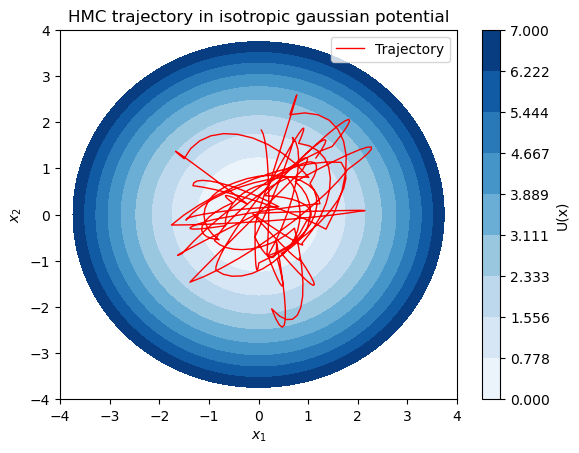

In [7]:
N=50

X,V = run_hmc(x0,v0, gradU_para, N, delta=0.19)
print(X.shape)
Xu, Yu, Ugrid = create_grid(U_para, grid_shape=4.0)

levels = np.linspace(0.0, 7.0, 10)

plt.contourf(
    Xu, Yu, Ugrid,
    levels=levels,
    cmap="Blues"
)
plt.colorbar(label="U(x)")

# overlay trajectory (optional)
plt.plot(X[:, 0], X[:, 1], color="red", lw=1, label='Trajectory')


plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("HMC trajectory in isotropic gaussian potential")


plt.legend()
plt.show()

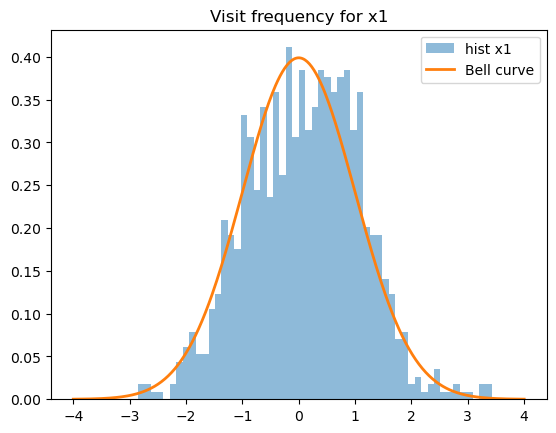

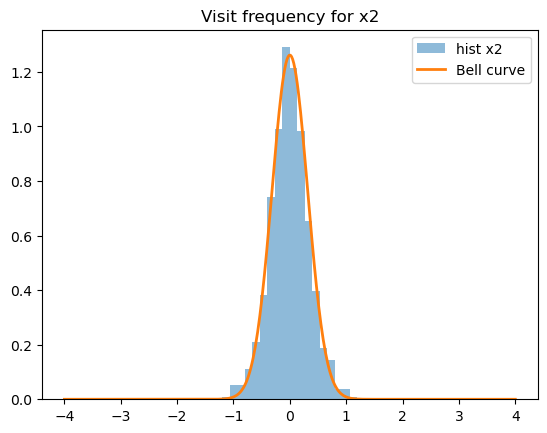

In [22]:
#Plotting histograms of visits of the potential
x1 = X[:,0]
x2 = X[:,1]

# plot histograms for the double well 
grid = np.linspace(-4, 4, 400)

def gaussian_pdf(x, sigma):
    return (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-0.5*(x/sigma)**2)

double_gauss = np.exp(-0.25*(grid**2 - 1)**2)

pdf_x1 = gaussian_pdf(grid, 1.0)
pdf_x2 = gaussian_pdf(grid, 1/np.sqrt(10))

plt.figure()
plt.hist(x1, bins=70, range=(-4, 4), density=True, alpha=0.5, label="hist x1")
plt.plot(grid, pdf_x1, lw=2, label="Bell curve")
plt.legend()
plt.title("Visit frequency for x1")
plt.show()

plt.figure()
plt.hist(x2, bins=60, range=(-4, 4),  density=True, alpha=0.5, label="hist x2")
plt.plot(grid, pdf_x2, lw=2, label="Bell curve")
plt.legend()
plt.title("Visit frequency for x2")
plt.show()

The next part of our analysis consists in visualizing regimes where the algorithm fails. 
This kind of regime is specific to HMC sampling, where $K>1$. 


Consider a case where we have an anisotropic gaussian potential 
$$U(x_1, x_2)= \frac{x_1^2}{2 \sigma_1^2} + \frac{x_2^2}{2 \sigma_2^2}, \text{ where } \sigma_1 >> \sigma_2$$
Then, in the case where $K \delta \approx T_i = 2 \pi \sigma_i$, where $T_i$ is the period of oscillation of the free particle in the marginal potential of $x_i$, Hamiltonian dynamics tells us that the variable $X$ will not explore the full range of one of the marginal gaussians, which are seperable, and will return to its starting point.



The goal is therefore to explore this regime, keeping $K$ fixed and sweeping $\delta$ in order to visualize these spikes in the time of convergence when $\delta$ nears the critical regime.


The question is: how to quantify this time of convergence? 


As a prelimminary analysis, we make a selection of observables $f_1, f_2, f_3...$ and compute the average of these observables in our target distribution $e^{-U}$ and compare it to $\frac{1}{N}\sum_{n=0}^{N} f_i(X_n)$. It is not ideal to choose $f(x) = x$ in this framework, as the mean is always $0$ for both marginals, and might give us a false idea of convergence. We then choose a threshold $\epsilon$, for which once every error (for each $f_i$) is below that threshold, we can consider our sampler has converged.


Once we have the
$n_{stop}$ for each $f_i$, we take the max or mean of them (max is more conservative and assures an upper bound for convergence time).

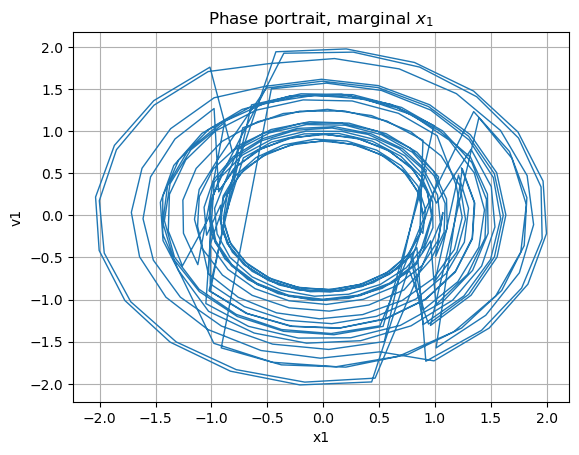

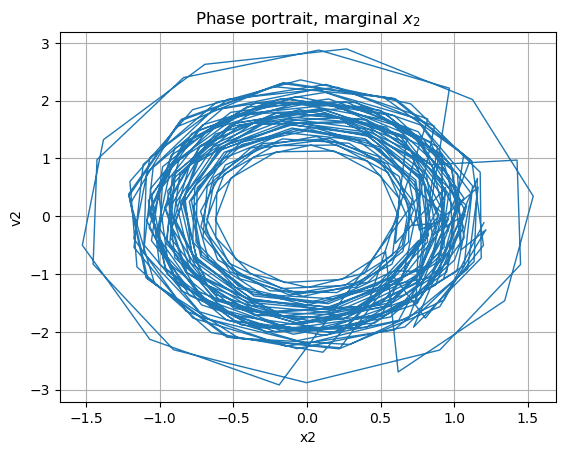

In [26]:
#phase portraits

def plot_phase_portraits(X, V, n_points=None):
    """
    X, V : arrays of shape (N*K, 2)
    n_points : optional truncation for clarity
    """
    if n_points is not None:
        X = X[:n_points]
        V = V[:n_points]

    # Mode 1: (x1, v1) -> circle
    plt.figure()
    plt.plot(X[:,0], V[:,0], lw=1)
    plt.xlabel("x1")
    plt.ylabel("v1")
    plt.title("Phase portrait, marginal $x_1$")
    plt.grid(True)

    # Mode 2: (x2, v2) -> ellipse
    plt.figure()
    plt.plot(X[:,1], V[:,1], lw=1)
    plt.xlabel("x2")
    plt.ylabel("v2")
    plt.title("Phase portrait, marginal $x_2$")
    plt.grid(True)

    plt.show()

X,V = run_hmc(x0,v0, gradU_anipara, N, delta=0.314)
plot_phase_portraits(X,V)


In [197]:
#convergence test for one or several test observables
def convergence_time_from_ensemble(X_ensemble, target_cov, eps=0.05, min_time=20):
    """
    Compute convergence time from an ensemble of trajectories.

    Parameters
    ----------
    X_ensemble : array of shape (n, T, d)
        Ensemble of position trajectories.
    target_cov : array of shape (d, d)
        Target second-moment matrix.
    eps : float
        Convergence tolerance.
    min_time : int
        Minimum number of steps before checking convergence.

    Returns
    -------
    t_conv : int
        Convergence time measured in number of gradient evaluations.
        Returns np.inf if convergence is not reached.
    """
    n, T, d = X_ensemble.shape

    for k in range(T):
        # all samples up to time k across all runs
        X_all = X_ensemble[:, :k, :].reshape(-1, d)  # shape (n*k, d)

        cov_k = empirical_cov(X_all)
        phi_k = np.linalg.norm(cov_k - target_cov)

        if phi_k < eps:
            return 2 * k   # 2 grad calls per Verlet step

    return np.inf
        


In [198]:
target_cov = np.array([[1.0, 0.0],
                       [0.0, 0.1]])

# initial condition
x0 = np.array([1.0, 1.0])
v0 = np.random.randn(2)

# sampler choice
sampler = run_hmc          # or run_k_langevin, run_od_langevin
gradU = gradU_anipara

# simulation parameters
delta = 0.1
eta = 0.0
N = 500          # number of Hamiltonian drifts
n = 50           # ensemble size
eps = 0.05

K_list = np.arange(1, 150)
conv_times = []

for K in K_list:

    X_ensemble, V_ensemble = several_runs(
        x0, v0,
        gradU,
        sampler,
        n=n,
        N=N,
        delta=delta,
        K=K,
        eta=eta
    )

    t_conv = convergence_time_from_ensemble(
        X_ensemble,
        target_cov,
        eps=eps
    )
    print(f"Running K = {K}, Conv Time = {t_conv}")
    conv_times.append(t_conv)

T = K_list * delta



C:\Users\julia\AppData\Local\Temp\ipykernel_22588\1486062257.py:61: RuntimeWarning: invalid value encountered in divide
  return (X.T @ X) / X.shape[0]


Running K = 1, Conv Time = inf
Running K = 2, Conv Time = 754
Running K = 3, Conv Time = 350
Running K = 4, Conv Time = 1368
Running K = 5, Conv Time = 186
Running K = 6, Conv Time = 104
Running K = 7, Conv Time = 210
Running K = 8, Conv Time = 504
Running K = 9, Conv Time = 2428
Running K = 10, Conv Time = inf
Running K = 11, Conv Time = 2790
Running K = 12, Conv Time = 838
Running K = 13, Conv Time = 716
Running K = 14, Conv Time = 332
Running K = 15, Conv Time = 1594
Running K = 16, Conv Time = 402
Running K = 17, Conv Time = 664
Running K = 18, Conv Time = 2176
Running K = 19, Conv Time = 7456
Running K = 20, Conv Time = inf
Running K = 21, Conv Time = 3696
Running K = 22, Conv Time = 2032
Running K = 23, Conv Time = 698
Running K = 24, Conv Time = 576
Running K = 25, Conv Time = 788
Running K = 26, Conv Time = 1028
Running K = 27, Conv Time = 1192
Running K = 28, Conv Time = 2894
Running K = 29, Conv Time = 11062
Running K = 30, Conv Time = inf
Running K = 31, Conv Time = 3762
Run

KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (149,) and (137,)

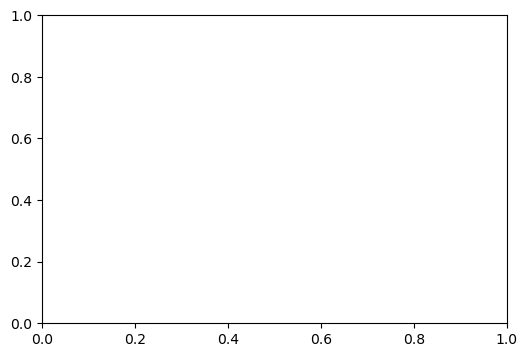

In [199]:
plt.figure(figsize=(6, 4))
plt.plot(T, conv_times)
plt.yscale("log")
plt.xlabel("Hamiltonian drift period T = Kδ")
plt.ylabel("Gradient evaluations to convergence")
plt.title("Convergence time vs Hamiltonian drift period")
plt.grid(True)
plt.tight_layout()
plt.show()

The goal of following cells is to visualize the 'forgetting initial velocity' phenomenon. It can be shown that $Cov(v_0, v_n)$, where $v_n$ is the velocity at step $n$, is a bounded oscillating function, which decreases to 0 in time. 

The goal could be to not only plot the evolution of this quantity throughout the trajectory, but also to plot it in function of the parameter $\gamma = \frac{1 - \eta}{K \delta}$, which is in reality the inverse of the 'half-life' of the covariance.

In [204]:
def covariance_vt_v0(V_ensemble):
    # Initial velocities for each run
    V0 = V_ensemble[:, 0, :]          # shape (n_runs, d)

    # V_ensemble * V0[:, None, :] -> (n_runs, T, d)
    cov = np.mean(V_ensemble * V0[:, None, :], axis=0)

    return cov #shape (N*K, d)


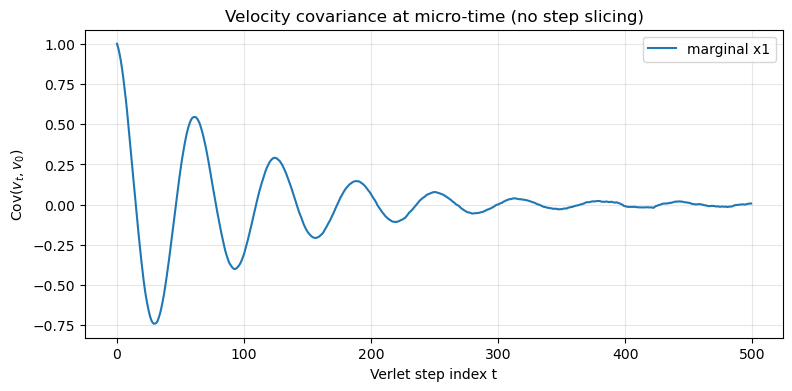

In [212]:
#parameters 
x0 = np.array([1.0,1.0])
v0 = np.random.randn(2)
eta = 0.98
delta = 0.1
K = 1

X_ens, V_ens = several_runs(x0, v0, gradU,sampler=run_k_langevin,n=20000,N=500,delta=delta,K=K,eta=eta)

cov = covariance_vt_v0(V_ens)




In [214]:
#function for bounding the oscillations
def theoretical_oscillation_constants(eta, delta):
    """
    Returns phi and C such that
    |Cov(v_t, v_0)| <= C * (sqrt(eta))^t
    """
    c = np.cos(delta)
    rho = np.sqrt(eta)

    cos_phi = (1 + eta) * c / (2 * rho)

    # numerical safety
    cos_phi = np.clip(cos_phi, -1.0, 1.0)
    phi = np.arccos(cos_phi)

    # amplitude coefficient A
    A = (eta * c - rho * cos_phi) / (rho * np.sin(phi))

    # global envelope constant
    C = np.sqrt(1 + A**2)

    return phi, C

def covariance_bounds(T, eta, delta):
    """
    Compute upper and lower theoretical bounds for Cov(v_t, v_0).

    Parameters
    ----------
    T : int
        number of time steps
    eta : float
        refreshment parameter
    delta : float
        Verlet time step (K=1)

    Returns
    -------
    lower, upper : arrays of shape (T,)
        theoretical bounds
    """
    _, C = theoretical_oscillation_constants(eta, delta)
    rho = np.sqrt(eta)

    t = np.arange(T)
    envelope = C * (rho ** t)

    return -envelope, envelope


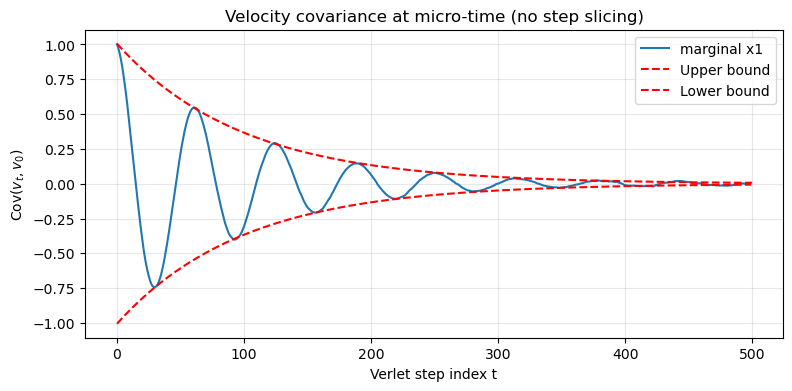

In [215]:
T = cov.shape[0]
t = np.arange(T)
lower, upper = covariance_bounds(T, eta, delta)

plt.figure(figsize=(9, 4))
#plot for marginal one
plt.plot(t, cov[:, 0], label=f"marginal x1")
plt.plot(t, upper, "r--", label="Upper bound")
plt.plot(t, lower, "r--", label="Lower bound")

plt.xlabel("Verlet step index t")
plt.ylabel(r"$\mathrm{Cov}(v_t, v_0)$")
plt.title("Velocity covariance at micro-time (no step slicing)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Frame number: 100
Frame number: 200
Frame number: 300


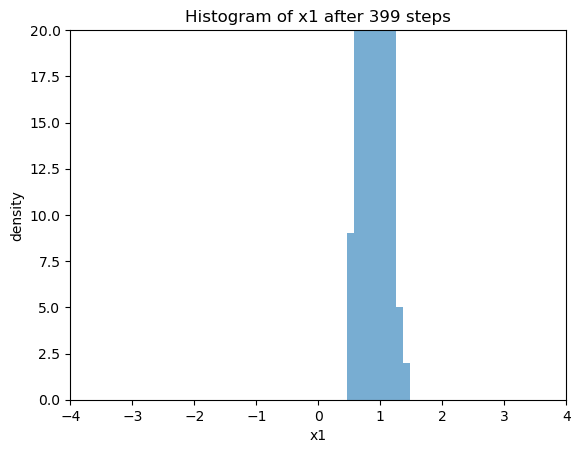

In [25]:
from matplotlib.animation import PillowWriter
fig, ax = plt.subplots()

metadata = dict(title='Histogram evolution', artist='julia')
writer = PillowWriter(fps=15, metadata=metadata)

with writer.saving(fig, "hist_evolution_nodensity.gif", dpi=100):
    for i in range(1, len(X)):  
        ax.clear()
        if i%100 == 0:
            print('Frame number:', i)
        ax.hist(
            X[:i, 0],
            bins=70,
            range=(-4, 4),
            density=False,
            alpha=0.6,
            color="tab:blue"
        )

        ax.set_xlim(-4, 4)
        ax.set_ylim(0, 20)
        ax.set_title(f"Histogram of x1 after {i} steps")
        ax.set_xlabel("x1")
        ax.set_ylabel("density")

        writer.grab_frame()


In [44]:
#Running an ensemble of trajectories 
M = 500          #number of trajectories
N = 3000   #length of each trajectory
d = 2

X_final = np.zeros((M, d))

for m in range(M):
    X = run_k_langevin(x0,v0, gradU_4para, N, delta=0.05)
    X_final[m] = X[-1]               #take final position on each trajectory



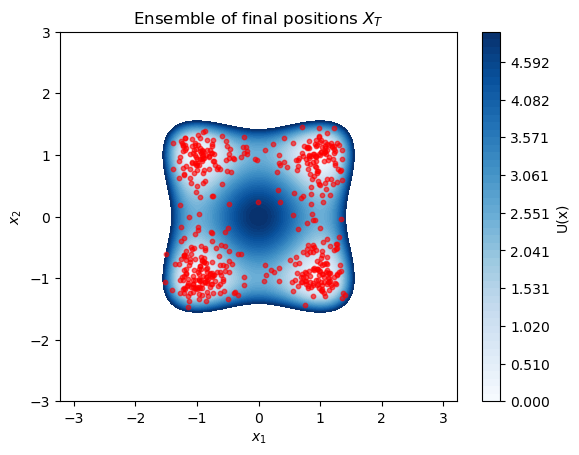

In [52]:

Xu, Yu, Ugrid = create_grid(U_4para, grid_shape=3.0)

levels = np.linspace(0.0, 5.0, 50)

plt.contourf(
    Xu, Yu, Ugrid,
    levels=levels,
    cmap="Blues"
)
plt.colorbar(label="U(x)")

plt.scatter(X_final[:,0], X_final[:,1], color='red', s=10, alpha=0.6)
plt.axis("equal")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Ensemble of final positions $X_T$")
plt.show()